# U-Net Semantic Segmentation (Morphological Extraction)
## Purpose of this Notebook
The objective of this phase is to train a **U-Net** semantic segmentation model. Unlike YOLO (which only draws bounding boxes), U-Net operates at the pixel level. Its job is to precisely color in the **Cytoplasm** and the **Nucleus** of the isolated cell. 
In the final pipeline, the output masks generated by this U-Net will be used to mathematically calculate the physical area of the nucleus and the Nucleus-to-Cytoplasm (NC) ratio, which are critical morphological features for diagnosing cervical cancer.

In [1]:
import os
import cv2
import torch
import glob
import numpy as np
from torch.utils.data import Dataset, DataLoader

### 1. Custom PyTorch Dataset & Mask Mapping
Standard PyTorch dataloaders cannot interpret colored segmentation masks. We engineered a custom `Dataset` class that loads the cell images alongside their ground-truth masks.
Crucially, this class maps the raw grayscale pixel values into categorical tensors:
* `Pixel 0` (Black) -> **Class 0** (Background)
* `Pixel 128` (Gray) -> **Class 1** (Cytoplasm)
* `Pixel 255` (White) -> **Class 2** (Nucleus)
Both inputs are resized to `128x128` to maintain computational efficiency while preserving morphological integrity.


In [2]:
class SIPaKMeD_UNet_Dataset(Dataset):
    def __init__(self, images_dir, masks_dir):
        self.images_dir = images_dir
        self.masks_dir = masks_dir
        # Find all .bmp images in the images folder
        self.image_files = glob.glob(os.path.join(images_dir, '*.bmp'))
        
    def __len__(self):
        return len(self.image_files)
    
    def __getitem__(self, idx):
        # 1. Load the Image
        img_path = self.image_files[idx]
        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB) # Convert to standard colors
        
        # 2. Load the matching Mask
        img_name = os.path.basename(img_path).replace('.bmp', '.png')
        mask_path = os.path.join(self.masks_dir, img_name)
        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
        
        # 3. Resize them both to 128x128 so they train fast on your laptop
        image = cv2.resize(image, (128, 128))
        mask = cv2.resize(mask, (128, 128), interpolation=cv2.INTER_NEAREST)
        
        # 4. Prepare for PyTorch (Math stuff)
        image = image.transpose(2, 0, 1).astype('float32') / 255.0
        
        # We have 3 classes: 0 (Background), 1 (Cytoplasm=128), 2 (Nucleus=255)
        mask_class = np.zeros_like(mask, dtype=np.int64)
        mask_class[mask == 128] = 1
        mask_class[mask == 255] = 2
        
        return torch.tensor(image), torch.tensor(mask_class)


In [3]:
from torch.utils.data import random_split
from torch.utils.data import DataLoader

In [4]:
unet_images = r"..\processed_data\unet_dataset\images"
unet_masks = r"..\processed_data\unet_dataset\masks"

In [5]:
dataset = SIPaKMeD_UNet_Dataset(unet_images, unet_masks)

train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

### 2. Validation Split and Data Loading
To ensure the U-Net model generalizes to unseen morphologies, we apply an **80/20 Validation Split**. 
The Training set (`shuffle=True`) teaches the AI, while the Validation set (`shuffle=False`) is locked away and strictly used to evaluate the model's accuracy after every epoch.


In [6]:
# We shuffle the train images, but we DON'T shuffle the val images!

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=8, shuffle=False)

print(f"Training on {train_size} images, Validating on {val_size} images.")

Training on 3239 images, Validating on 810 images.


In [7]:
import sys
!{sys.executable} -m pip install segmentation-models-pytorch



[notice] A new release of pip available: 22.3.1 -> 26.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [8]:
import segmentation_models_pytorch as smp
import torch.nn as nn
import torch.optim as optim

e:\SIPaKMeD\sipakmed_env\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### 3. Transfer Learning Architecture (U-Net + ResNet34)
Rather than training a neural network entirely from scratch, we employ **Transfer Learning** to maximize feature extraction and accelerate convergence. 
We instantiate a U-Net architecture powered by a **ResNet-34 Encoder**. By setting `encoder_weights="imagenet"`, the model initializes with deep layers that already possess an advanced understanding of shapes, edges, and gradients, requiring us only to fine-tune the final layers for cellular segmentation.

In [9]:
# Creating the U-Net Model
# We use 'resnet34' as the brain because it is fast and highly accurate.
# classes=3 because we have: 0(Background), 1(Cytoplasm), 2(Nucleus)
model = smp.Unet(
    encoder_name="resnet34",     
    encoder_weights="imagenet",  # Uses pre-learned weights to train faster
    in_channels=3,               # 3 colors (RGB image)
    classes=3                    
)

In [10]:
# Turn on your GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)
print(f"Using device: {device}\n")

Using device: cuda



In [11]:
# Setup the Math for learning
criterion = nn.CrossEntropyLoss() # Standard math formula for checking segmentation errors
optimizer = optim.Adam(model.parameters(), lr=0.001)
print("Starting U-Net Training... \n")

Starting U-Net Training... 



### Transfer Learning Architecture (U-Net + ResNet34)
Rather than training a neural network entirely from scratch, we employ **Transfer Learning** to maximize feature extraction and accelerate convergence. 
We instantiate a U-Net architecture powered by a **ResNet-34 Encoder**. By setting `encoder_weights="imagenet"`, the model initializes with deep layers that already possess an advanced understanding of shapes, edges, and gradients, requiring us only to fine-tune the final layers for cellular segmentation.


In [ ]:
# # Train model
# epochs = 50
# patience = 10 
# best_val_loss = float('inf')
# patience_counter = 0

# # Store math data
# train_losses = []
# val_losses = []
# train_accuracies = []
# val_accuracies = []

# for epoch in range(epochs):
#     # Training
#     model.train()
#     running_train_loss = 0.0
#     correct_train = 0
#     total_train = 0
    
#     # Loop through the dataloader we made in the previous step
#     for images, masks in train_loader:
#         # Send data to the GPU
#         images = images.to(device)
#         masks = masks.to(device)
        
#         # Step A: The model looks at the image and guesses the mask
#         optimizer.zero_grad()
#         predictions = model(images)
        
#         # Step B: Calculate how wrong the guess was (The Loss)
#         loss = criterion(predictions, masks)
        
#         # Step C: The A.I. updates its brain to do better next time!
#         loss.backward()
#         optimizer.step()
        
#         running_train_loss += loss.item()

#         pred_masks = torch.argmax(predictions, dim=1)
#         correct_train += (pred_masks == masks).sum().item()
#         total_train += masks.numel()
        
#     # Get average train loss for this epoch
#     avg_train_loss = running_train_loss / len(train_loader)
#     avg_train_acc = (correct_train / total_train) * 100

#     train_losses.append(avg_train_loss)
#     train_accuracies.append(avg_train_acc)

#     # Validation
#     model.eval()
#     running_val_loss = 0.0
#     correct_val = 0     
#     total_val = 0  

#     with torch.no_grad():
#         for images, masks in val_loader:
#             images, masks = images.to(device), masks.to(device)
#             predictions = model(images)
            
#             loss = criterion(predictions, masks)
#             running_val_loss += loss.item()

#             pred_masks = torch.argmax(predictions, dim=1)
#             correct_val += (pred_masks == masks).sum().item()
#             total_val += masks.numel()

#     avg_val_loss = running_val_loss / len(val_loader)
#     avg_val_acc = (correct_val / total_val) * 100
    
#     val_losses.append(avg_val_loss)
#     val_accuracies.append(avg_val_acc)
    
#     print(f"Epoch [{epoch+1}/{epochs}] - Train Loss: {avg_train_loss:.4f}, Acc: {avg_train_acc:.2f}% | Val Loss: {avg_val_loss:.4f}, Acc: {avg_val_acc:.2f}%")
    
#     # Early Stoping
#     if avg_val_loss < best_val_loss:
#         best_val_loss = avg_val_loss
#         patience_counter = 0 # Reset patience

#         # Save the absolute best version of the model!
#         os.makedirs(r'..\trained_models\unet', exist_ok=True)
#         torch.save(model.state_dict(), r'..\trained_models\unet\unet_sipakmed.pth')
#     else:
#         patience_counter += 1
        
#         if patience_counter >= patience:
#             print(f"\nEarly stopping triggered! The model started overfitting after {epoch+1} epochs.")
            
#             break # Kills the loop early!

# print("\nTraining Complete! The best weights have been saved.")

Epoch [1/50] - Train Loss: 0.3080, Acc: 87.14% | Val Loss: 0.2379, Acc: 89.96%
Epoch [2/50] - Train Loss: 0.2218, Acc: 90.66% | Val Loss: 0.2294, Acc: 90.34%
Epoch [3/50] - Train Loss: 0.2018, Acc: 91.46% | Val Loss: 0.2226, Acc: 90.81%
Epoch [4/50] - Train Loss: 0.1871, Acc: 92.01% | Val Loss: 0.2587, Acc: 88.78%
Epoch [5/50] - Train Loss: 0.1777, Acc: 92.43% | Val Loss: 0.1938, Acc: 91.78%
Epoch [6/50] - Train Loss: 0.1721, Acc: 92.66% | Val Loss: 0.1868, Acc: 92.12%
Epoch [7/50] - Train Loss: 0.1611, Acc: 93.09% | Val Loss: 0.1899, Acc: 92.04%
Epoch [8/50] - Train Loss: 0.1543, Acc: 93.37% | Val Loss: 0.1797, Acc: 92.47%
Epoch [9/50] - Train Loss: 0.1466, Acc: 93.68% | Val Loss: 0.1802, Acc: 92.64%
Epoch [10/50] - Train Loss: 0.1421, Acc: 93.88% | Val Loss: 0.1782, Acc: 92.65%
Epoch [11/50] - Train Loss: 0.1445, Acc: 93.80% | Val Loss: 0.1812, Acc: 92.54%
Epoch [12/50] - Train Loss: 0.1323, Acc: 94.28% | Val Loss: 0.1824, Acc: 92.79%
Epoch [13/50] - Train Loss: 0.1232, Acc: 94.66% |

In [13]:
%matplotlib inline
import matplotlib.pyplot as plt

### Evaluating the Morphological Features
With training complete, we extract the mathematical metrics stored during the loop to plot the Learning Curves. A divergence between Training Loss (decreasing) and Validation Loss (increasing) clearly visualizes the exact moment the Early Stopping algorithm triggered to prevent overfitting.
Finally, we feed a random batch of unseen validation images into the locked AI to visually confirm its ability to physically trace the cytoplasm and nucleus!

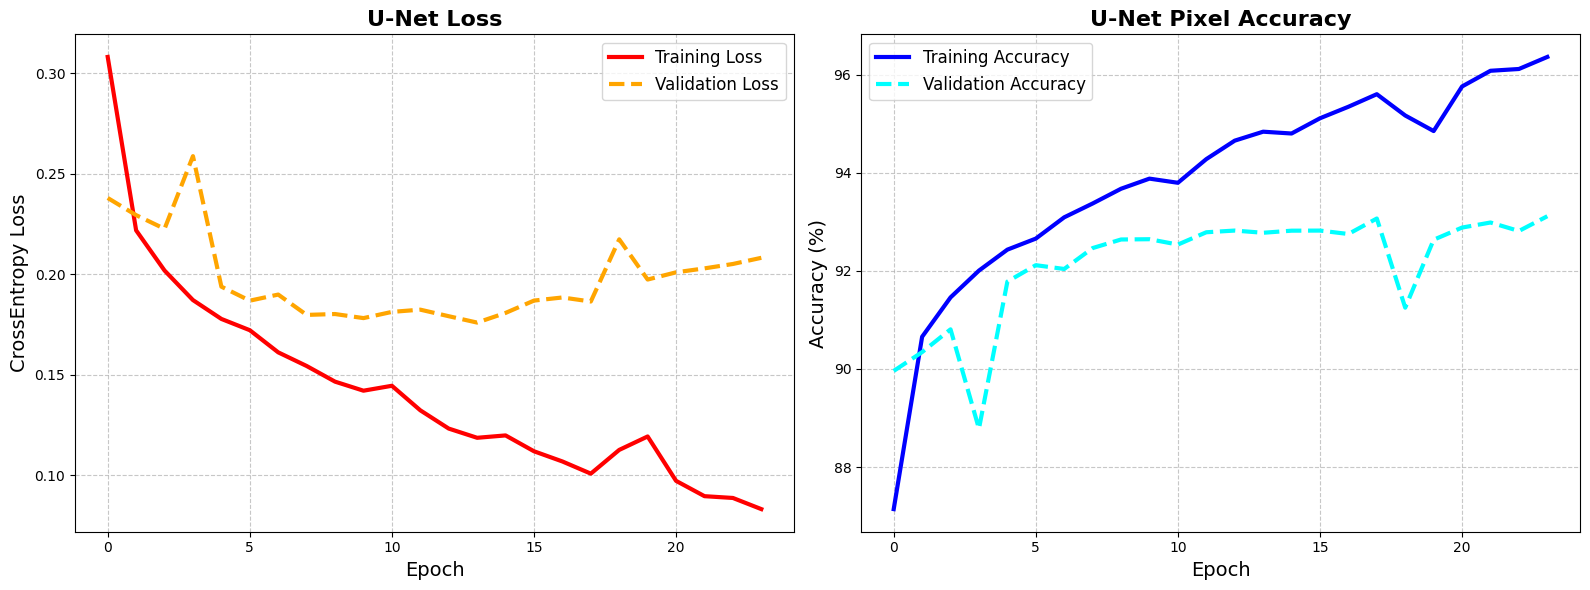

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].plot(train_losses, label='Training Loss', color='red', linewidth=3)
axes[0].plot(val_losses, label='Validation Loss', color='orange', linewidth=3, linestyle='--')
axes[0].set_title('U-Net Loss', fontsize=16, fontweight='bold')
axes[0].set_xlabel('Epoch', fontsize=14)
axes[0].set_ylabel('CrossEntropy Loss', fontsize=14)
axes[0].grid(True, linestyle='--', alpha=0.7)
axes[0].legend(fontsize=12)

axes[1].plot(train_accuracies, label='Training Accuracy', color='blue', linewidth=3)
axes[1].plot(val_accuracies, label='Validation Accuracy', color='cyan', linewidth=3, linestyle='--')
axes[1].set_title('U-Net Pixel Accuracy', fontsize=16, fontweight='bold')
axes[1].set_xlabel('Epoch', fontsize=14)
axes[1].set_ylabel('Accuracy (%)', fontsize=14)
axes[1].grid(True, linestyle='--', alpha=0.7)
axes[1].legend(fontsize=12)
plt.tight_layout()
plt.show()

In [15]:
model.eval()
images, true_masks = next(iter(val_loader))
images = images.to(device)

with torch.no_grad():
    predictions = model(images)
    pred_masks = torch.argmax(predictions, dim=1).cpu().numpy()

images = images.cpu().numpy().transpose(0, 2, 3, 1) 
true_masks = true_masks.cpu().numpy()

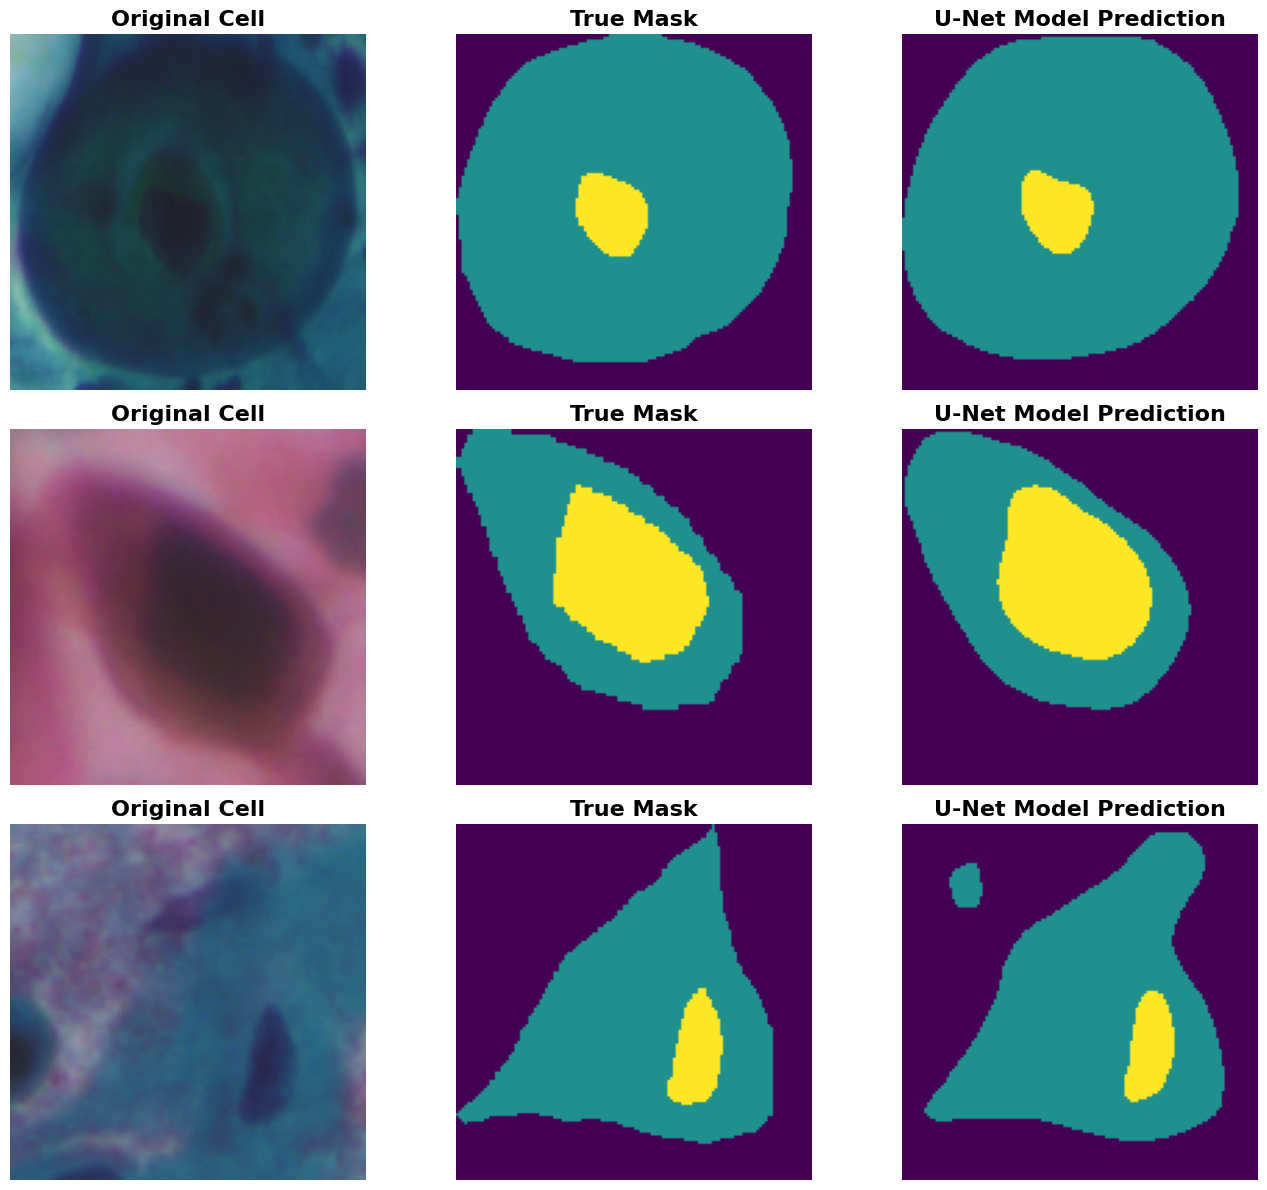

In [16]:
fig, axes = plt.subplots(3, 3, figsize=(14, 12))

for i in range(3):
    # Column 1: Original Image
    axes[i, 0].imshow(images[i])
    axes[i, 0].axis('off')
    axes[i, 0].set_title("Original Cell", fontsize=16, fontweight='bold')
    
    # Column 2: Ground Truth Mask
    axes[i, 1].imshow(true_masks[i], cmap='viridis')
    axes[i, 1].axis('off')
    axes[i, 1].set_title("True Mask", fontsize=16, fontweight='bold')
    
    # Column 3: U-Net Predicted Mask
    axes[i, 2].imshow(pred_masks[i], cmap='viridis')
    axes[i, 2].axis('off')
    axes[i, 2].set_title("U-Net Model Prediction", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()